# Structure

We have split this implementation into two scripts. kinematics_functions.py contains only general functions and mathematical models that can be used independently of what robot arm you are analyzing. kuka_arm_analysis.ipynb contains all variables spesific to the kuka arm problem, and the implementation of code that answers the provided questions using the functions from kinematics_functions.py. 

# PACKAGES

In [1]:
%matplotlib widget
import numpy as np
from kinematics_functions import *

3.141592653589793


# VARIABLES
In the cell below, all required variables for the kuka arm are defined, including the DH table derived in question 1.

In [2]:
# d values (not provided in the problem, so these are just estimates)
d_3 = 1 # Upper arm length
d_5 = 1 # Forearm length
d_7 = 1 # Hand length

h = 0.001 # Step size for numerical differentiation

# DH_table
def DH(q):
    return np.array([
        # d,    theta,  a,  alpha
        [0,     q[0],   0,  np.pi/2 ],
        [0,     q[1],   0, -np.pi/2 ],
        [d_3,   q[2],   0, -np.pi/2 ],
        [0,     q[3],   0,  np.pi/2 ],
        [d_5,   q[4],   0,  np.pi/2 ],
        [0,     q[5],   0, -np.pi/2 ],
        [d_7,   q[6],   0,  0       ],
    ])



# Question 4

## Part 1 - Verifying the Geometric Jacobian by comparing to direct kinematics


Geometric Jacobian at q = [0.0, 0.5, 0.0, -0.5, 0.0, 0.5, 0.0]:
[[ 0.000 -1.489  0.000  0.611  0.000 -0.071 -0.000]
 [-2.318 -0.000 -1.321 -0.000 -0.479 -0.000  0.000]
 [ 0.000 -2.318  0.000  1.839  0.000 -0.997  0.000]
 [ 0.000  0.000 -0.479 -0.000 -0.841 -0.000 -0.997]
 [ 0.000 -1.000 -0.000  1.000 -0.000 -1.000 -0.000]
 [ 1.000  0.000  0.878  0.000  0.540  0.000  0.071]]

Numerical Jacobian at q = [0.0, 0.5, 0.0, -0.5, 0.0, 0.5, 0.0]:
[[ 0.001 -1.487  0.001  0.612  0.000 -0.070  0.000]
 [-2.318 -0.000 -1.321 -0.000 -0.479 -0.000  0.000]
 [ 0.000 -2.319  0.000  1.839  0.000 -0.998  0.000]
 [ 0.000 -0.000 -0.479 -0.000 -0.841 -0.000 -0.997]
 [-0.000 -1.000 -0.000  1.000 -0.000 -1.000  0.000]
 [ 1.000  0.000  0.878  0.000  0.540  0.000  0.071]]

Max difference vs analytical: 1.16e-03


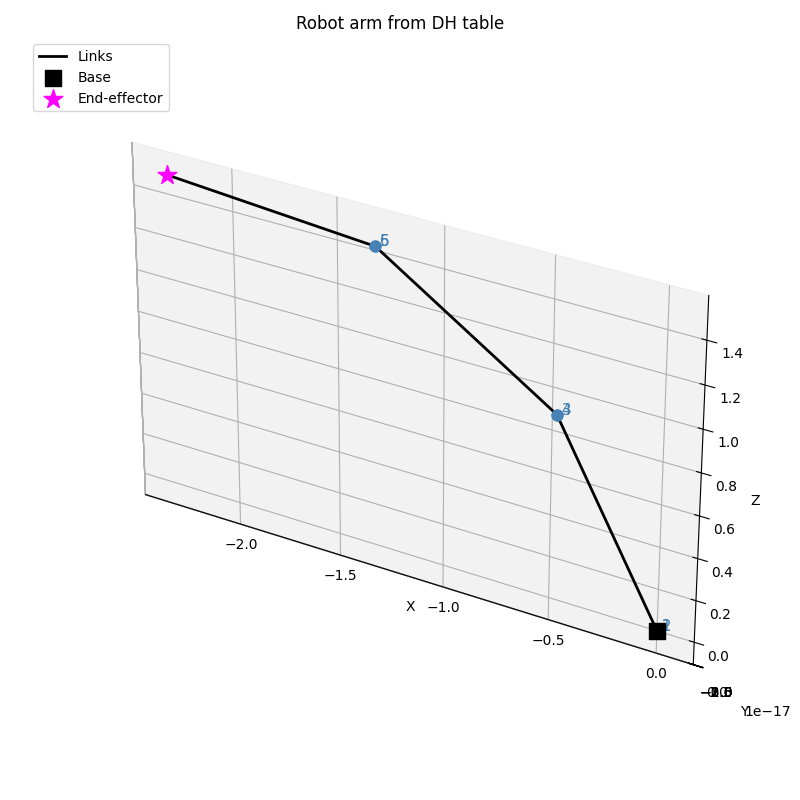

In [3]:
q = np.array([0.0, 0.5, 0.0, -0.5, 0.0, 0.5, 0.0]) # Example joint angles, all close to zero to avoid singularities

J = geometric_jacobian_from_DH_table(DH(q))
print("Geometric Jacobian at q = [0.0, 0.5, 0.0, -0.5, 0.0, 0.5, 0.0]:")
print(np.array2string(J, precision=3, suppress_small=True, floatmode='fixed'))


# ---- Numerical verification via direct kinematics ----
N = len(q)
T_0 = n_T_n_from_DH_table(DH(q), 0, N)
p_0, R_0 = T_0[:3, 3], T_0[:3, :3]

J_num = np.zeros((6, N))
for i in range(N):
    q_h = q.copy()
    q_h[i] += h
    T_h = n_T_n_from_DH_table(DH(q_h), 0, N)
    dR = T_h[:3, :3] @ R_0.T   # ≈ I + [omega]_x * h for small h

    J_num[:3, i] = (T_h[:3, 3] - p_0) / h
    J_num[3:, i] = [dR[2,1] - dR[1,2],
                    dR[0,2] - dR[2,0],
                    dR[1,0] - dR[0,1]]
    J_num[3:, i] /= 2*h

print("\nNumerical Jacobian at q = [0.0, 0.5, 0.0, -0.5, 0.0, 0.5, 0.0]:")
print(np.array2string(J_num, precision=3, suppress_small=True, floatmode='fixed'))
print(f"\nMax difference vs analytical: {np.max(np.abs(J - J_num)):.2e}")

plot_robot_from_DH_table(DH(q)) # Visualize the robot in the configuration defined by q


We see that there is only a small difference between the geometric jacobian we calculated and the one we found via numerical differentiation and direct kinematics, indicating strongly that our expression for the numerical jacobian is correct.

## Part 2 - Inspecting the Jacobian close to singularities

---- Elbow stretched  (theta_4 = 0) ----
q (rad):        [0.  0.5 0.  0.  0.5 0.5 0. ]
J:
[[ 0.230 -2.324  0.202  1.446  0.202 -0.446  0.000]
 [-1.749 -0.000 -0.421  0.000 -0.421 -0.421  0.000]
 [ 0.000 -1.749  0.110  1.269  0.110 -0.790  0.000]
 [ 0.000  0.000 -0.479 -0.000 -0.479  0.421 -0.790]
 [ 0.000 -1.000 -0.000  1.000 -0.000 -0.878 -0.230]
 [ 1.000  0.000  0.878  0.000  0.878  0.230  0.568]]
singular values: [3.934 2.481 1.274 0.645 0.241 0.   ]
rank(J) = 5 / 6
sigma_min     = 2.075e-16
condition num = 1.896e+16

---- Wrist singularity  (theta_6 = 0) ----
q (rad):        [0.3 0.5 0.  0.7 0.  0.  0.4]
J:
[[ 0.024 -2.711 -0.381  1.873  0.000 -0.936  0.000]
 [-0.078 -0.839  1.231  0.579  0.000 -0.290  0.000]
 [ 0.000 -0.082 -0.000 -0.397  0.000  0.199  0.000]
 [ 0.000  0.296 -0.458 -0.296  0.190  0.296  0.190]
 [ 0.000 -0.955 -0.142  0.955  0.059 -0.955  0.059]
 [ 1.000  0.000  0.878  0.000  0.980  0.000  0.980]]
singular values: [3.946 2.039 1.216 0.651 0.251 0.176]
rank(J) = 6 /

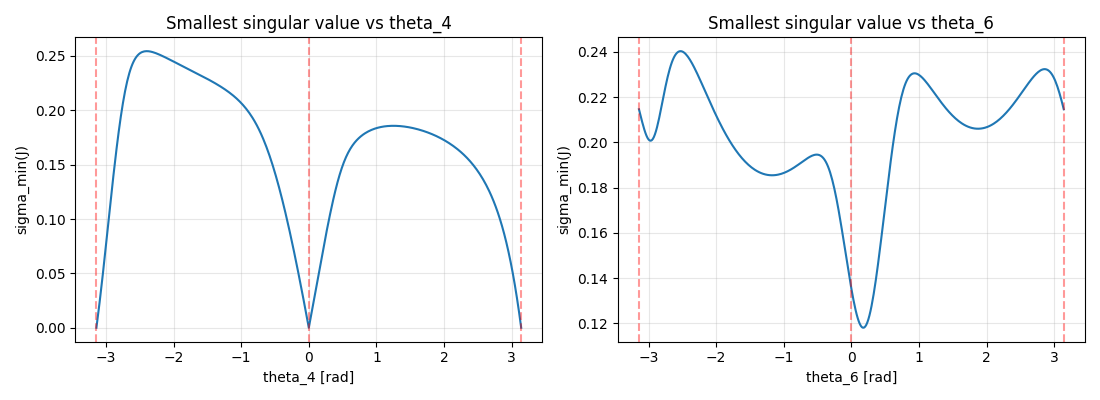

In [4]:
# ---- Inspect Jacobian rank/condition near singularities ----
import matplotlib.pyplot as plt

def inspect(label, q):
    J_q = geometric_jacobian_from_DH_table(DH(q))
    sv = np.linalg.svd(J_q, compute_uv=False)
    rank = np.linalg.matrix_rank(J_q)
    print(f"---- {label} ----")
    print("q (rad):       ", np.array2string(q, precision=3, suppress_small=True))
    print("J:")
    print(np.array2string(J_q, precision=3, suppress_small=True, floatmode='fixed'))
    print("singular values:", np.array2string(sv, precision=3, suppress_small=True))
    print(f"rank(J) = {rank} / 6")
    print(f"sigma_min     = {sv[-1]:.3e}")
    print(f"condition num = {sv[0]/sv[-1]:.3e}\n")

# 1) Elbow stretched: theta_4 = 0
inspect("Elbow stretched  (theta_4 = 0)",
        np.array([0.0, 0.5, 0.0, 0.0, 0.5, 0.5, 0.0]))

# 2) Wrist roll singularity: theta_6 = 0
inspect("Wrist singularity  (theta_6 = 0)",
        np.array([0.3, 0.5, 0.0, 0.7, 0.0, 0.0, 0.4]))

# 3) Wrist sits on z_0: q_2 = 0 and q_4 = 0 (arm aligned with the base axis)
inspect("Wrist on z_0  (q_2 = 0, q_4 = 0)",
        np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0]))

# 4) Folded arm: q_4 = pi -> elbow and wrist-on-z_0 coincide because d_3 = d_5
inspect("Folded arm  (q_4 = pi)",
        np.array([0.3, 0.4, 0.0, np.pi, 0.0, 0.5, 0.0]))


# ---- Sweep through the singular angles to show sigma_min collapsing ----
# Baseline: every joint slightly bent so we are well away from any singularity,
# then vary one joint at a time and watch the smallest singular value of J.
baseline = np.array([0.3, 0.5, 0.0, 0.7, 0.5, 0.5, 0.4])

def sweep(joint_idx, angles):
    sigmas = []
    for t in angles:
        q = baseline.copy()
        q[joint_idx] = t
        sv = np.linalg.svd(geometric_jacobian_from_DH_table(DH(q)), compute_uv=False)
        sigmas.append(sv[-1])
    return np.array(sigmas)

angles = np.linspace(-np.pi, np.pi, 401)
sigma_min_t4 = sweep(3, angles)   # joint index 3 = theta_4
sigma_min_t6 = sweep(5, angles)   # joint index 5 = theta_6

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, sigmas, name in zip(axes, [sigma_min_t4, sigma_min_t6], ['theta_4', 'theta_6']):
    ax.plot(angles, sigmas)
    for s in [-np.pi, 0.0, np.pi]:
        ax.axvline(s, ls='--', color='red', alpha=0.4)
    ax.set_xlabel(f'{name} [rad]')
    ax.set_ylabel('sigma_min(J)')
    ax.set_title(f'Smallest singular value vs {name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Question 5

## Part 1 - CLIK implementation



==== Desired ====
Position: [1.500 0.500 1.500]
Rotation:
[[1.000 0.000 0.000]
 [0.000 1.000 0.000]
 [0.000 0.000 1.000]]

==== Achieved by CLIK after 80 iterations ====
Position: [1.499 0.500 1.500]
Rotation:
[[ 1.000 -0.000 -0.000]
 [ 0.000  1.000  0.000]
 [ 0.000 -0.000  1.000]]

==== Joint configuration found by CLIK (rad) ====
[ 0.380 -1.855  0.099 -1.187 -0.153  0.675 -0.232]


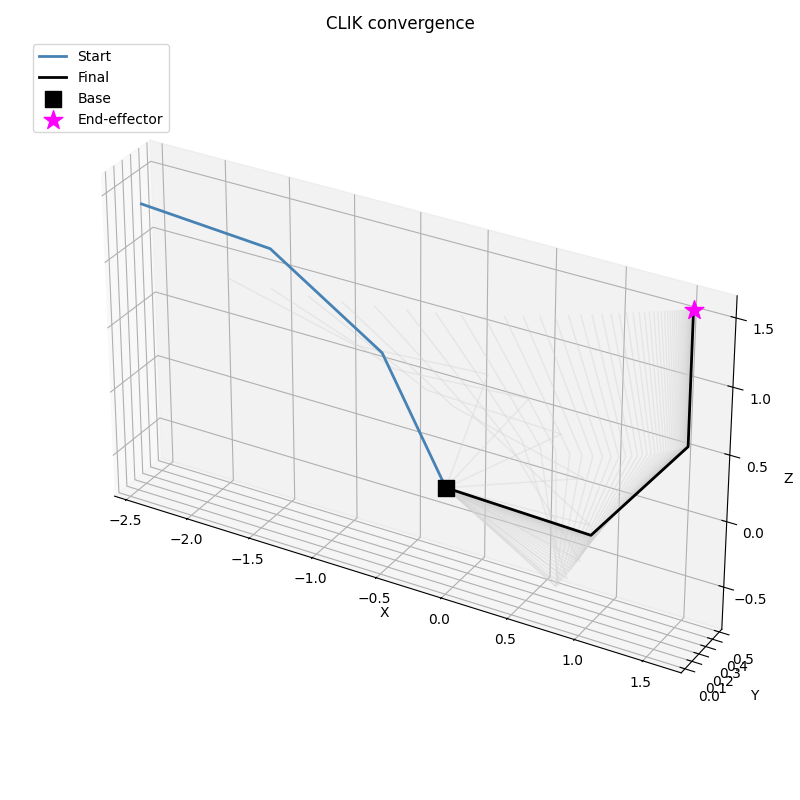

In [5]:
# ---- CLIK execution ----
# Desired end-effector pose (static target: no feedforward velocity).
p_d     = np.array([1.5, 0.5, 1.5])
R_d     = np.eye(3)
p_d_dot = np.zeros(3)
omega_d = np.zeros(3)

# Initial configuration (slightly bent so the convergence path is visible).
q_start     = np.array([0.0, 0.5, 0.0, -0.5, 0.0, 0.5, 0.0])
q_dot_start = np.zeros(7)

# Jacobian as a function of q (recomputed each iteration inside CLIK).
J_func = lambda q: geometric_jacobian_from_DH_table(DH(q))

q_final, q_dot_final, q_history = CLIK(
    p_d, R_d, omega_d, p_d_dot, q_start, q_dot_start,
    J=J_func, DH_func=DH,
)

# Achieved pose for comparison.
T_final = n_T_n_from_DH_table(DH(q_final), 0, len(q_final))
p_final = T_final[:3, 3]
R_final = T_final[:3, :3]

fmt = dict(precision=3, suppress_small=True, floatmode='fixed')

print("==== Desired ====")
print("Position:", np.array2string(p_d, **fmt))
print("Rotation:")
print(np.array2string(R_d, **fmt))

print(f"\n==== Achieved by CLIK after {len(q_history) - 1} iterations ====")
print("Position:", np.array2string(p_final, **fmt))
print("Rotation:")
print(np.array2string(R_final, **fmt))

print("\n==== Joint configuration found by CLIK (rad) ====")
print(np.array2string(q_final, **fmt))

plot_CLIK_convergence(q_history, DH)



## Part 2 - Validation against task 3

==== Desired pose ====
p_d: [0.5000 0.3000 1.8000]
R_d:
[[1.0000 0.0000 0.0000]
 [0.0000 1.0000 0.0000]
 [0.0000 0.0000 1.0000]]

==== Closed-form IK ====
q_cf [rad]:     [ 0.5404  0.4232  0.0000  2.1060  3.1416 -1.6828  2.6012]
Reconstructed p: [0.5000 0.3000 1.8000]
Position    error: 3.724e-16
Orientation error: 2.351e-16

==== CLIK ====
Iterations: 75
q_clik [rad]:   [ 0.2862 -1.6607 -0.1713 -2.1062 -0.3813 -0.4734  0.0410]
Reconstructed p: [0.4993 0.2998 1.8000]
Position    error: 7.647e-04
Orientation error: 4.768e-04

==== Cross-check ====
Both methods reach the same task-space pose to high precision.
The joint configurations differ because of the manipulator's redundancy:
the closed form enforces q_3 = 0, CLIK leaves q_3 free.
||q_cf - q_clik||:       6.527e+00
q_3 (closed form):       0.000e+00   (= 0 by construction)
q_3 (CLIK):              -1.713e-01   (free)
||p_cf - p_clik||:       7.647e-04
||R_cf - R_clik||:       4.768e-04


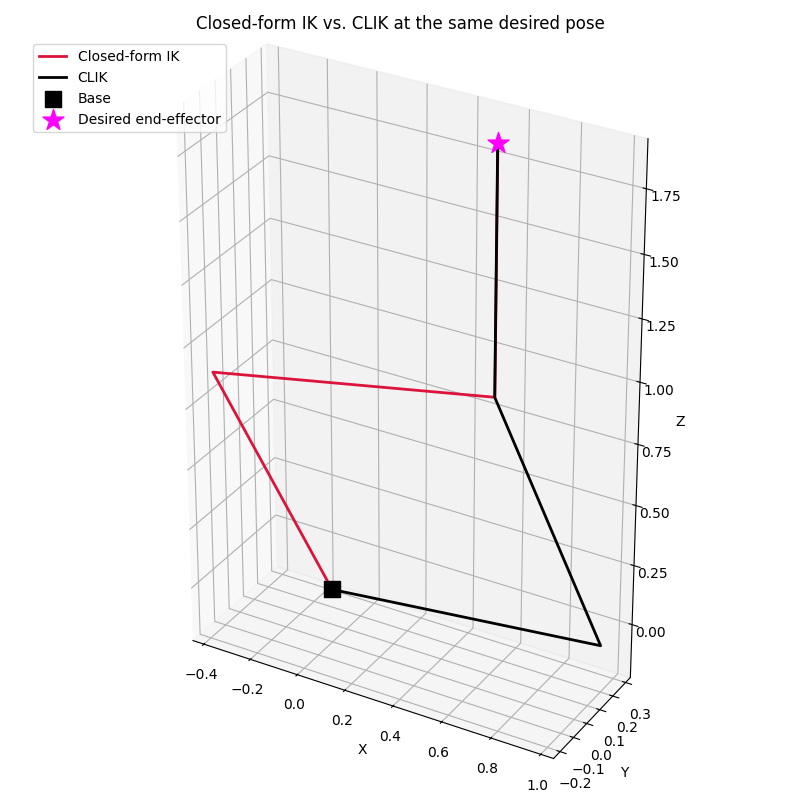

In [6]:
# ---- CLIK vs. closed-form inverse kinematics ----
# Implements the kinematic-decoupling method from Section 5 of the report
# (wrist-centre split, q_3 = 0 to remove the redundancy). The exact algebra in
# the report assumes a planar-arm convention where q_2 = pi/2 is the upright
# arm and the wrist orientation is ZYZ in (q_6, q_5, q_7) order, neither of
# which matches the DH chain we use here:
#   - in our DH, q_2 = 0 (not pi/2) is the upright arm,
#   - the wrist factorisation is R_7_4 = Rz(q_5) * Ry(-q_6) * Rz(q_7), so the
#     ZYZ alpha corresponds to q_5 and beta to -q_6 (not q_5).
# The function below is the same method, with these adaptations.

def closed_form_IK(p_d, R_d, elbow_sign=+1):
    # Wrist centre: subtract the last link along the end-effector z-axis.
    z_hat = R_d[:, 2]
    p_w   = p_d - d_7 * z_hat
    x_w, y_w, z_w = p_w

    # --- Position sub-problem ---
    q_1 = np.arctan2(y_w, x_w)
    r   = np.sqrt(x_w**2 + y_w**2)
    cos_q4 = np.clip((r**2 + z_w**2 - d_3**2 - d_5**2) / (2*d_3*d_5), -1.0, 1.0)
    sin_q4 = elbow_sign * np.sqrt(1.0 - cos_q4**2)
    q_4 = np.arctan2(sin_q4, cos_q4)
    A = d_3 + d_5 * np.cos(q_4)
    B = d_5 * np.sin(q_4)
    q_2 = np.arctan2(B, A) - np.arctan2(r, z_w)   # adapted for q_2=0 upright
    q_3 = 0.0

    # --- Orientation sub-problem ---
    q_partial = np.array([q_1, q_2, q_3, q_4, 0.0, 0.0, 0.0])
    R_0_4 = n_T_n_from_DH_table(DH(q_partial), 0, 4)[:3, :3]
    R_7_4 = R_0_4.T @ R_d

    # ZYZ extraction with beta = -q_6 (our wrist is Rz(q_5) Ry(-q_6) Rz(q_7)).
    s_beta = np.sqrt(R_7_4[0,2]**2 + R_7_4[1,2]**2)
    if s_beta < 1e-9:
        # Gimbal lock: split the rotation between q_5 and q_7 (here, all into q_5).
        q_5 = np.arctan2(R_7_4[1,0], R_7_4[0,0])
        q_6 = 0.0
        q_7 = 0.0
    else:
        q_5 = np.arctan2(R_7_4[1,2], R_7_4[0,2])
        q_6 = -np.arctan2(s_beta, R_7_4[2,2])
        q_7 = np.arctan2(R_7_4[2,1], -R_7_4[2,0])

    return np.array([q_1, q_2, q_3, q_4, q_5, q_6, q_7])


# Desired pose (reachable for the unit-length link assumption d_3 = d_5 = d_7 = 1).
p_d_val = np.array([0.5, 0.3, 1.8])
R_d_val = np.eye(3)

# --- Method A: closed-form IK ---
q_cf = closed_form_IK(p_d_val, R_d_val)
T_cf = n_T_n_from_DH_table(DH(q_cf), 0, 7)
p_cf, R_cf = T_cf[:3, 3], T_cf[:3, :3]

# --- Method B: CLIK, starting from a deliberately different initial config ---
q_start_val = np.array([0.1, 0.3, 0.0, -0.3, 0.0, 0.3, 0.0])
J_func = lambda q: geometric_jacobian_from_DH_table(DH(q))
q_clik, _, q_history = CLIK(
    p_d_val, R_d_val, np.zeros(3), np.zeros(3),
    q_start_val, np.zeros(7), J=J_func, DH_func=DH,
)
T_clik = n_T_n_from_DH_table(DH(q_clik), 0, 7)
p_clik, R_clik = T_clik[:3, 3], T_clik[:3, :3]

# --- Compare task-space outputs ---
fmt = dict(precision=4, suppress_small=True, floatmode='fixed')

print("==== Desired pose ====")
print("p_d:", np.array2string(p_d_val, **fmt))
print("R_d:")
print(np.array2string(R_d_val, **fmt))

print("\n==== Closed-form IK ====")
print("q_cf [rad]:    ", np.array2string(q_cf,  **fmt))
print("Reconstructed p:", np.array2string(p_cf, **fmt))
print(f"Position    error: {np.linalg.norm(p_cf - p_d_val):.3e}")
print(f"Orientation error: {np.linalg.norm(R_cf - R_d_val):.3e}")

print("\n==== CLIK ====")
print(f"Iterations: {len(q_history) - 1}")
print("q_clik [rad]:  ", np.array2string(q_clik, **fmt))
print("Reconstructed p:", np.array2string(p_clik, **fmt))
print(f"Position    error: {np.linalg.norm(p_clik - p_d_val):.3e}")
print(f"Orientation error: {np.linalg.norm(R_clik - R_d_val):.3e}")

print("\n==== Cross-check ====")
print("Both methods reach the same task-space pose to high precision.")
print("The joint configurations differ because of the manipulator's redundancy:")
print("the closed form enforces q_3 = 0, CLIK leaves q_3 free.")
print(f"||q_cf - q_clik||:       {np.linalg.norm(q_cf - q_clik):.3e}")
print(f"q_3 (closed form):       {q_cf[2]:.3e}   (= 0 by construction)")
print(f"q_3 (CLIK):              {q_clik[2]:.3e}   (free)")
print(f"||p_cf - p_clik||:       {np.linalg.norm(p_cf - p_clik):.3e}")
print(f"||R_cf - R_clik||:       {np.linalg.norm(R_cf - R_clik):.3e}")


# --- Visual comparison: closed-form (red) vs. CLIK (black) on the same axes ---
def get_origins(q):
    DH_table = DH(q)
    return np.array([n_T_n_from_DH_table(DH_table, 0, i)[:3, 3]
                     for i in range(len(DH_table) + 1)])

o_cf   = get_origins(q_cf)
o_clik = get_origins(q_clik)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(o_cf[:, 0],   o_cf[:, 1],   o_cf[:, 2],
        '-', color='crimson', linewidth=2, label='Closed-form IK')
ax.plot(o_clik[:, 0], o_clik[:, 1], o_clik[:, 2],
        '-', color='black',   linewidth=2, label='CLIK')

ax.scatter(*o_cf[0],    color='black',   marker='s', s=120, label='Base')
ax.scatter(*p_d_val,    color='magenta', marker='*', s=250, label='Desired end-effector')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Closed-form IK vs. CLIK at the same desired pose')
ax.legend(loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
